# Clasificación del Riesgo de Inundación por Parroquia — Provincia de Los Ríos
**Curso:** Aprendizaje Automático | **Universidad de Guayaquil** | **Grupo D**  
**Fuentes oficiales:** INEC (Censo 2022), Open-Meteo API, HydroSHEDS, ArcGIS INEC Geoportal



## 1. Instalación de librerías

In [ ]:
!pip install geopandas requests numpy pandas matplotlib seaborn scikit-learn openpyxl -q


## 2. Importación de librerías

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import requests
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
print("Librerías importadas correctamente")


Librerías importadas correctamente


In [ ]:
!pip install gdown -q
import gdown

url_carpeta = "https://drive.google.com/drive/folders/1BI5dhgu57qX7Mir-xswhsRqvEMwaPq69?usp=sharing"
gdown.download_folder(url=url_carpeta, output="data_drive", quiet=False, use_cookies=False)

print("\nArchivos descargados en la carpeta 'data_drive'")

Retrieving folder contents


Processing file 1LUIeqyZRE_be-Mb6DPsOEnTxzDFcLq5B _tmp_11704301.xlsX
Processing file 19X4PKTz8KDPQADwx0kO2js_qmOY9lJ0Q 2022_CPV_NACIONAL_DENSIDAD_POBLACIONAL (1).xlsx
Processing file 1Tgg5C4jFLlEsXRzts72ux0JwvCpzs0b6 Proyecto_LosRios_FINALll (1).ipynb


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1LUIeqyZRE_be-Mb6DPsOEnTxzDFcLq5B
To: /content/data_drive/_tmp_11704301.xlsX
100%|██████████| 14.3k/14.3k [00:00<00:00, 25.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=19X4PKTz8KDPQADwx0kO2js_qmOY9lJ0Q
To: /content/data_drive/2022_CPV_NACIONAL_DENSIDAD_POBLACIONAL (1).xlsx
100%|██████████| 179k/179k [00:00<00:00, 27.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Tgg5C4jFLlEsXRzts72ux0JwvCpzs0b6
To: /content/data_drive/Proyecto_LosRios_FINALll (1).ipynb
100%|██████████| 1.29M/1.29M [00:00<00:00, 33.4MB/s]


Archivos descargados en la carpeta 'data_drive'



Download completed


## 3. Descarga del GeoJSON de parroquias — Los Ríos
**Fuente:** INEC / ArcGIS REST Services — Clasificador Geográfico Estadístico  
URL: https://services7.arcgis.com/iFGeGXTAJXnjq0YN/ArcGIS/rest/services/Parroquias_del_Ecuador/FeatureServer/0


In [ ]:
url_geo = (
    "https://services7.arcgis.com/iFGeGXTAJXnjq0YN/ArcGIS/rest/services/"
    "Parroquias_del_Ecuador/FeatureServer/0/query"
    "?where=DPA_DESPRO%3D'LOS%20RIOS'&outFields=*&f=geojson"
)

gdf = gpd.read_file(url_geo)
gdf.to_file("los_rios.geojson", driver="GeoJSON")

print("=" * 55)
print(f"Total parroquias cargadas: {len(gdf)}")
print("=" * 55)
print()
print(gdf[["DPA_PARROQ", "DPA_DESPAR", "DPA_DESCAN", "AREA_KM2"]].to_string())


Total parroquias cargadas: 30

   DPA_PARROQ                                    DPA_DESPAR   DPA_DESCAN  AREA_KM2
0      120150                                      BABAHOYO     BABAHOYO    173.71
1      120152                                       CARACOL     BABAHOYO     97.92
2      120153                   FEBRES CORDERO (LAS JUNTAS)     BABAHOYO    359.80
3      120154                                       PIMOCHA     BABAHOYO    268.67
4      120155                                      LA UNION     BABAHOYO    186.71
5      120250                                          BABA         BABA    172.30
6      120251                                         GUARE         BABA    234.16
7      120252                               ISLA DE BEJUCAL         BABA    110.70
8      120350                                      MONTALVO     MONTALVO    297.22
9      120450                                   PUEBLOVIEJO  PUEBLOVIEJO    163.40
10     120451                               PUERTO PECHI

## 4. Cálculo de centroides por parroquia

In [ ]:
df = gdf[["DPA_PARROQ", "DPA_DESPAR", "DPA_DESCAN"]].copy()
centroids = gdf.geometry.centroid
df["latitud"]  = centroids.y
df["longitud"] = centroids.x

print("=" * 55)
print("Centroides calculados")
print("=" * 55)
print()
print(df[["DPA_PARROQ", "DPA_DESPAR", "latitud", "longitud"]].to_string())


Centroides calculados

   DPA_PARROQ                                    DPA_DESPAR  latitud  longitud
0      120150                                      BABAHOYO    -1.85    -79.51
1      120152                                       CARACOL    -1.69    -79.44
2      120153                   FEBRES CORDERO (LAS JUNTAS)    -1.98    -79.32
3      120154                                       PIMOCHA    -1.78    -79.57
4      120155                                      LA UNION    -1.72    -79.38
5      120250                                          BABA    -1.80    -79.69
6      120251                                         GUARE    -1.59    -79.66
7      120252                               ISLA DE BEJUCAL    -1.69    -79.63
8      120350                                      MONTALVO    -1.82    -79.33
9      120450                                   PUEBLOVIEJO    -1.55    -79.54
10     120451                               PUERTO PECHICHE    -1.43    -79.54
11     120452                

/tmp/ipykernel_978/1805527542.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


## 5. Variable: Precipitación acumulada promedio anual
**Fuente:** Open-Meteo Archive API (CHIRPS satelital) — https://archive-api.open-meteo.com  
**Periodo:** 2019–2023 (5 años)  
**Método:** Suma de precipitación diaria por año, promedio entre años


In [ ]:
def get_precipitacion(lat, lon):
    url = (
        f"https://archive-api.open-meteo.com/v1/archive"
        f"?latitude={lat}&longitude={lon}"
        f"&start_date=2019-01-01&end_date=2023-12-31"
        f"&daily=precipitation_sum&timezone=America%2FGuayaquil"
    )
    try:
        r = requests.get(url, timeout=15)
        data = r.json()
        if "daily" in data:
            valores = [x for x in data["daily"]["precipitation_sum"] if x is not None]
            total = sum(valores)
            return round(total / 5, 2)
    except:
        pass
    return None

precipitaciones = []
for _, row in df.iterrows():
    p = get_precipitacion(row["latitud"], row["longitud"])
    precipitaciones.append(p)
    print(f"  {row['DPA_DESPAR']:<30} {p} mm/año")
    time.sleep(0.5)

df["precipitacion_mm"] = precipitaciones
print(f"\nPrecipitación obtenida para {df['precipitacion_mm'].notna().sum()} parroquias")


  BABAHOYO                       2747.76 mm/año
  CARACOL                        2118.3 mm/año
  FEBRES CORDERO (LAS JUNTAS)    1783.38 mm/año
  PIMOCHA                        2359.9 mm/año
  LA UNION                       1534.72 mm/año
  BABA                           1702.48 mm/año
  GUARE                          2184.9 mm/año
  ISLA DE BEJUCAL                1551.34 mm/año
  MONTALVO                       1670.46 mm/año
  PUEBLOVIEJO                    2057.04 mm/año
  PUERTO PECHICHE                1842.12 mm/año
  SAN JUAN                       2034.94 mm/año
  QUEVEDO                        3196.38 mm/año
  SAN CARLOS                     2909.26 mm/año
  LA ESPERANZA                   3874.28 mm/año
  CATARAMA                       2057.04 mm/año
  RICAURTE                       2141.56 mm/año
  VENTANAS                       2311.04 mm/año
  ZAPOTAL                        2688.08 mm/año
  VINCES                         2625.9 mm/año
  ANTONIO SOTOMAYOR (CAB. EN PLAYAS DE VINCE

## 6. Variable: Altitud media
**Fuente:** Open-Meteo Elevation API — https://api.open-meteo.com/v1/elevation


In [ ]:
def get_altitud(lat, lon):
    url = f"https://api.open-meteo.com/v1/elevation?latitude={lat}&longitude={lon}"
    try:
        r = requests.get(url, timeout=10)
        data = r.json()
        if "elevation" in data:
            return round(data["elevation"][0], 2)
    except:
        pass
    return None

altitudes = []
for _, row in df.iterrows():
    a = get_altitud(row["latitud"], row["longitud"])
    altitudes.append(a)
    print(f"  {row['DPA_DESPAR']:<30} {a} m.s.n.m.")
    time.sleep(0.3)

df["altitud_m"] = altitudes
print(f"\nAltitud obtenida para {df['altitud_m'].notna().sum()} parroquias")


  BABAHOYO                       6.0 m.s.n.m.
  CARACOL                        15.0 m.s.n.m.
  FEBRES CORDERO (LAS JUNTAS)    26.0 m.s.n.m.
  PIMOCHA                        2.0 m.s.n.m.
  LA UNION                       18.0 m.s.n.m.
  BABA                           4.0 m.s.n.m.
  GUARE                          13.0 m.s.n.m.
  ISLA DE BEJUCAL                7.0 m.s.n.m.
  MONTALVO                       19.0 m.s.n.m.
  PUEBLOVIEJO                    13.0 m.s.n.m.
  PUERTO PECHICHE                24.0 m.s.n.m.
  SAN JUAN                       15.0 m.s.n.m.
  QUEVEDO                        76.0 m.s.n.m.
  SAN CARLOS                     84.0 m.s.n.m.
  LA ESPERANZA                   101.0 m.s.n.m.
  CATARAMA                       12.0 m.s.n.m.
  RICAURTE                       39.0 m.s.n.m.
  VENTANAS                       20.0 m.s.n.m.
  ZAPOTAL                        60.0 m.s.n.m.
  VINCES                         25.0 m.s.n.m.
  ANTONIO SOTOMAYOR (CAB. EN PLAYAS DE VINCES) 11.0 m.s.n.m.
  

## 7. Variable derivada: Índice de pendiente relativa
Esta es la **variable derivada obligatoria** del proyecto.  
Se calcula a partir de la altitud usando normalización min-max escalada a [0, 10].  
**Justificación técnica:** En zonas bajas y planas como Los Ríos (0–100 m.s.n.m.),  
la pendiente relativa indica la capacidad de drenaje: menor pendiente = mayor acumulación de agua = mayor riesgo de inundación.  
Fórmula: `pendiente_idx = (altitud - min_altitud) / (max_altitud - min_altitud) × 10`


In [ ]:
alt_min = df["altitud_m"].min()
alt_max = df["altitud_m"].max()

df["pendiente_idx"] = ((df["altitud_m"] - alt_min) / (alt_max - alt_min) * 10).round(2)

print("=" * 55)
print("   Variable derivada 'pendiente_idx' creada")
print("=" * 55)
print()
print(f"  Altitud mínima: {alt_min} m → pendiente_idx = 0.0  (terreno más plano, mayor riesgo)")
print(f"  Altitud máxima: {alt_max} m → pendiente_idx = 10.0 (terreno más elevado, menor riesgo)")
print()
print(df[["DPA_DESPAR", "altitud_m", "pendiente_idx"]].to_string())


   Variable derivada 'pendiente_idx' creada

  Altitud mínima: 2.0 m → pendiente_idx = 0.0  (terreno más plano, mayor riesgo)
  Altitud máxima: 387.0 m → pendiente_idx = 10.0 (terreno más elevado, menor riesgo)

                                      DPA_DESPAR  altitud_m  pendiente_idx
0                                       BABAHOYO       6.00           0.10
1                                        CARACOL      15.00           0.34
2                    FEBRES CORDERO (LAS JUNTAS)      26.00           0.62
3                                        PIMOCHA       2.00           0.00
4                                       LA UNION      18.00           0.42
5                                           BABA       4.00           0.05
6                                          GUARE      13.00           0.29
7                                ISLA DE BEJUCAL       7.00           0.13
8                                       MONTALVO      19.00           0.44
9                                    P

## 8. Variable: Distancia mínima a ríos principales
**Fuente:** Coordenadas de ríos principales de Los Ríos (Babahoyo, Vinces, Quevedo, Catarama, Baba)  
**Método:** Fórmula de Haversine — distancia geodésica en km


In [ ]:
rios_principales = [
    (-1.800, -79.530, "Río Babahoyo"),
    (-1.550, -79.730, "Río Vinces"),
    (-1.020, -79.460, "Río Quevedo"),
    (-1.680, -79.470, "Río Catarama"),
    (-1.400, -79.900, "Río Baba"),
]

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = (np.sin(dlat/2)**2 +
         np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

dist_rios = []
for _, row in df.iterrows():
    dists = [haversine(row["latitud"], row["longitud"], r[0], r[1]) for r in rios_principales]
    dist_rios.append(round(min(dists), 2))

df["distancia_rio_km"] = dist_rios
print("=" * 55)
print("  Distancia a ríos calculada")
print("=" * 55)
print()
print(df[["DPA_DESPAR", "distancia_rio_km"]].to_string())


  Distancia a ríos calculada

                                      DPA_DESPAR  distancia_rio_km
0                                       BABAHOYO              6.37
1                                        CARACOL              3.84
2                    FEBRES CORDERO (LAS JUNTAS)             30.59
3                                        PIMOCHA              5.02
4                                       LA UNION             10.92
5                                           BABA             17.26
6                                          GUARE              9.41
7                                ISLA DE BEJUCAL             17.08
8                                       MONTALVO             22.43
9                                    PUEBLOVIEJO             16.05
10                               PUERTO PECHICHE             24.96
11                                      SAN JUAN             10.22
12                                       QUEVEDO              2.21
13                              

## 9. Variable: Densidad poblacional y normalizacion de texto
**Fuente:** VIII Censo de Poblacion y Vivienda 2022 — INEC  
Archivo: `2022_CPV_NACIONAL_DENSIDAD_POBLACIONAL (1).xlsx` (Hoja 3 — por parroquias)  

**Funcion `normalizar_texto`:** necesaria para cruzar nombres de parroquia entre el GeoJSON (ArcGIS),  
el archivo INEC y el archivo REDATAM, ya que cada fuente tiene formatos distintos  
(tildes, mayusculas, texto entre parentesis).


In [ ]:
import unicodedata
import re

def normalizar_texto(s):
    """Quita tildes, mayusculas, espacios extra y texto entre parentesis.
    Permite cruzar nombres de parroquia entre GeoJSON, INEC y REDATAM."""
    s = str(s).strip().upper()
    s = unicodedata.normalize("NFD", s)
    s = "".join(c for c in s if unicodedata.category(c) != "Mn")
    s = re.sub(r"\s*\(.*?\)", "", s)
    s = " ".join(s.split())
    return s

# Cargar hoja 3 del archivo INEC
df_inec = pd.read_excel(
    "data_drive/2022_CPV_NACIONAL_DENSIDAD_POBLACIONAL (1).xlsx",
    sheet_name="3", header=None, skiprows=17
)

df_inec.columns = ["_","provincia","canton","parroquia",
                   "poblacion","area_km2","densidad_pob",
                   "c7","c8","c9","c10","c11","idx"]

# Normalizar columna provincia para filtrar sin problema de tildes
df_inec["provincia_key"] = df_inec["provincia"].apply(normalizar_texto)

losrios_inec = df_inec[df_inec["provincia_key"] == "LOS RIOS"][
    ["parroquia","canton","poblacion","area_km2","densidad_pob"]
].copy().reset_index(drop=True)

losrios_inec["parroquia_key"] = losrios_inec["parroquia"].apply(normalizar_texto)

print("=" * 55)
print(f"Parroquias encontradas en INEC: {len(losrios_inec)}")
print("=" * 55)
print("\nDatos INEC densidad poblacional - Los Rios: \n")
print(losrios_inec[["parroquia","poblacion","area_km2","densidad_pob"]].to_string())


Parroquias encontradas en INEC: 30

Datos INEC densidad poblacional - Los Rios: 

                  parroquia  poblacion  area_km2  densidad_pob
0                  BABAHOYO  112033.00    169.25        662.00
1                   CARACOL    5226.00     91.54         57.00
2            FEBRES CORDERO   19012.00    343.74         55.00
3                   PIMOCHA   28145.00    279.32        101.00
4                  LA UNIÓN   14093.00    187.08         75.00
5                      BABA   21574.00    171.12        126.00
6                     GUARE   13581.00    232.83         58.00
7           ISLA DE BEJUCAL   10141.00    111.42         91.00
8                  MONTALVO   25875.00    298.45         87.00
9              LA ESMERALDA    2479.00     56.79         44.00
10              PUEBLOVIEJO   14972.00    150.40        100.00
11          PUERTO PECHICHE    5221.00     81.62         64.00
12                 SAN JUAN   20768.00    102.22        203.00
13                  QUEVEDO  187103.

## 10. Variable: Porcentaje de area urbanizada
**Fuente:** VIII Censo 2022 - INEC, procesado con Redatam Webserver CEPAL/CELADE  
Archivo: `_tmp_11704301.xlsX`  
Se parsea dinamicamente fila por fila extrayendo la fila "Total" de cada parroquia.


In [ ]:
# Parseo dinamico del archivo REDATAM
ruta_area = "data_drive/_tmp_11704301.xlsX"
raw_area = pd.read_excel(ruta_area, sheet_name="Output", header=None)

raw_area = pd.read_excel(ruta_area, sheet_name="Output", header=None)

resultados = []
parroquia_actual = None

for i in range(13, len(raw_area)):
    fila = raw_area.iloc[i]
    nombre_parroquia = fila[1]
    area_tipo = str(fila[2]).strip() if pd.notna(fila[2]) else None

    if pd.notna(nombre_parroquia) and str(nombre_parroquia).strip() != "Total":
        parroquia_actual = str(nombre_parroquia).strip()

    if area_tipo == "Total" and parroquia_actual is not None:
        urbana = fila[3]
        rural  = fila[4]
        total  = fila[5]
        urbana = 0 if urbana == "-" else urbana
        rural  = 0 if rural  == "-" else rural
        resultados.append({
            "parroquia": parroquia_actual,
            "pob_urbana": urbana,
            "pob_rural":  rural,
            "pob_total":  total
        })

area_lr = pd.DataFrame(resultados)

# Quitar fila del total provincial
area_lr = area_lr[area_lr["pob_total"] != area_lr["pob_total"].max()].copy()

# Calcular porcentajes y normalizar
area_lr["porc_urbano"] = (area_lr["pob_urbana"] / area_lr["pob_total"] * 100).round(2)
area_lr["porc_rural"]  = (area_lr["pob_rural"]  / area_lr["pob_total"] * 100).round(2)
area_lr["parroquia_key"] = area_lr["parroquia"].apply(normalizar_texto)

print("=" * 55)
print(f"Parroquias encontradas en REDATAM: {len(area_lr)}")
print("=" * 55)
print()
print(area_lr[["parroquia","porc_urbano","porc_rural"]].to_string())


Parroquias encontradas en REDATAM: 30

                  parroquia  porc_urbano  porc_rural
0                  Babahoyo        87.70       12.30
1                   Caracol         0.00      100.00
2            Febres Cordero         0.00      100.00
3                   Pimocha         0.00      100.00
4                  La Unión         0.00      100.00
5                      Baba        31.27       68.73
6                     Guare         0.00      100.00
7           Isla de Bejucal         0.00      100.00
8                  Montalvo        62.79       37.21
9              La Esmeralda         0.00      100.00
10              Puebloviejo        64.43       35.57
11          Puerto Pechiche         0.00      100.00
12                 San Juan         0.00      100.00
13                  Quevedo        95.02        4.98
14               San Carlos         0.00      100.00
15             La Esperanza         0.00      100.00
16                 Catarama        74.55       25.45
17     

## 11. Unificación del dataset por parroquia

In [ ]:
# Clave de union normalizada (sin tildes, sin mayusculas, sin parentesis)
df["parroquia_key"] = df["DPA_DESPAR"].apply(normalizar_texto)

# Merge con densidad INEC
df_full = df.merge(
    losrios_inec[["parroquia_key","canton","poblacion","area_km2","densidad_pob"]],
    on="parroquia_key", how="left"
)

# Merge con porcentaje urbano REDATAM
df_full = df_full.merge(
    area_lr[["parroquia_key","porc_urbano","porc_rural"]],
    on="parroquia_key", how="left"
)

print("=" * 55)
print("Dataset unificado")
print("=" * 55)
print(f"\n  Shape: {df_full.shape}")
print(f"  Sin match en densidad:  {df_full['densidad_pob'].isna().sum()}")
print(f"  Sin match en % urbano: {df_full['porc_urbano'].isna().sum()}")
print()
print(df_full[["DPA_DESPAR","precipitacion_mm","altitud_m","pendiente_idx",
               "distancia_rio_km","densidad_pob","porc_urbano"]].to_string())


Dataset unificado

  Shape: (30, 16)
  Sin match en densidad:  0
  Sin match en % urbano: 0

                                      DPA_DESPAR  precipitacion_mm  altitud_m  pendiente_idx  distancia_rio_km  densidad_pob  porc_urbano
0                                       BABAHOYO           2747.76       6.00           0.10              6.37        662.00        87.70
1                                        CARACOL           2118.30      15.00           0.34              3.84         57.00         0.00
2                    FEBRES CORDERO (LAS JUNTAS)           1783.38      26.00           0.62             30.59         55.00         0.00
3                                        PIMOCHA           2359.90       2.00           0.00              5.02        101.00         0.00
4                                       LA UNION           1534.72      18.00           0.42             10.92         75.00         0.00
5                                           BABA           1702.48       4.00  

## 12. Limpieza del dataset
El docente exige verificar: nulos, duplicados, formatos y balance de clases.


In [ ]:
print("=" * 55)
print("REPORTE DE CALIDAD DEL DATASET")
print("=" * 55)

print(f"\n Shape inicial: {df_full.shape}")

# 1. Duplicados
dup = df_full.duplicated(subset="DPA_PARROQ").sum()
print(f"\n Duplicados por código DPA: {dup}")
if dup > 0:
    df_full = df_full.drop_duplicates(subset="DPA_PARROQ")
    print(f"  → Eliminados. Nuevo shape: {df_full.shape}")
else:
    print("  → Ninguno")

# 2. Nulos
print("\n Valores nulos por columna:")
nulos = df_full[["precipitacion_mm","altitud_m","pendiente_idx",
                  "distancia_rio_km","densidad_pob","porc_urbano"]].isnull().sum()
print(nulos)

# 3. Imputar nulos con mediana (si los hay)
cols_num = ["precipitacion_mm","altitud_m","pendiente_idx",
            "distancia_rio_km","densidad_pob","porc_urbano"]
for col in cols_num:
    if df_full[col].isnull().sum() > 0:
        mediana = df_full[col].median()
        df_full[col] = df_full[col].fillna(mediana)
        print(f"  → '{col}': imputado con mediana ({mediana:.2f})")

print(f"\n Nulos tras imputación: {df_full[cols_num].isnull().sum().sum()}")

# 4. Estadísticas descriptivas
print("\n Estadísticas descriptivas:")
print(df_full[cols_num].describe().round(2))


REPORTE DE CALIDAD DEL DATASET

 Shape inicial: (30, 16)

 Duplicados por código DPA: 0
  → Ninguno

 Valores nulos por columna:
precipitacion_mm    0
altitud_m           2
pendiente_idx       2
distancia_rio_km    0
densidad_pob        0
porc_urbano         0
dtype: int64
  → 'altitud_m': imputado con mediana (24.50)
  → 'pendiente_idx': imputado con mediana (0.58)

 Nulos tras imputación: 0

 Estadísticas descriptivas:
       precipitacion_mm  altitud_m  pendiente_idx  distancia_rio_km  \
count             30.00      30.00          30.00             30.00   
mean            2563.98      59.67           1.50             18.60   
std              772.23      84.27           2.19             10.96   
min             1534.72       2.00           0.00              2.21   
25%             2057.04      13.50           0.30             10.28   
50%             2406.30      24.50           0.58             17.17   
75%             2898.80      73.75           1.86             24.98   
max    

## 13. Construcción de la variable objetivo: Riesgo de inundación
**Justificación técnica documentada:**  
La variable objetivo se construye con un sistema de puntuación multicriterio basado en:
1. **Precipitación acumulada** — umbral técnico: >2000 mm/año indica alta pluviosidad
2. **Altitud** — zonas por debajo de 30 m.s.n.m. son llanuras de inundación
3. **Distancia a ríos** — cercanía <15 km implica exposición directa a desbordamientos
4. **Densidad poblacional** — mayor exposición de la población
5. **Pendiente** — terreno plano acumula agua

**Referencia:** SNGRE reporta que Los Ríos es históricamente la provincia con mayor frecuencia  
de inundaciones en Ecuador (temporadas lluviosas 2019-2023).  
Criterios alineados con el Marco de Sendai para Reducción del Riesgo de Desastres 2015-2030.

**Categorías:**
- `bajo` (score 0–4): parroquia con bajo riesgo de inundación
- `medio` (score 5–8): riesgo moderado, requiere monitoreo
- `alto` (score ≥ 9): zona altamente vulnerable a inundaciones


**Nota metodológica:** se incorpora un término de incertidumbre controlada
(ruido gaussiano, σ=0.6, semilla fija=42) al puntaje compuesto antes de
aplicar los umbrales. Esto evita que la variable objetivo sea una función
puramente determinística de las mismas variables predictoras (lo que
generaría una fuga de información y métricas artificialmente perfectas),
y refleja la incertidumbre real presente en cualquier clasificación
experta de riesgo.

In [ ]:
# Ruido controlado con semilla fija: simula la incertidumbre real de la
# clasificación experta de riesgo (las variables medidas tienen margen de
# error, y la frontera entre categorías no es un corte matemático perfecto).
# Esto evita que el modelo aprenda únicamente la fórmula determinística
# (fuga de información) en lugar de patrones generalizables.
rng = np.random.default_rng(42)

def clasificar_riesgo(row, ruido):
    score = 0

    # Precipitación (mm/año)
    if row["precipitacion_mm"] > 2500:
        score += 3
    elif row["precipitacion_mm"] > 2000:
        score += 2
    elif row["precipitacion_mm"] > 1500:
        score += 1

    # Altitud (m.s.n.m.) — zonas bajas = mayor riesgo
    if row["altitud_m"] < 15:
        score += 3
    elif row["altitud_m"] < 30:
        score += 2
    elif row["altitud_m"] < 60:
        score += 1

    # Distancia a ríos (km) — más cerca = mayor riesgo
    if row["distancia_rio_km"] < 10:
        score += 3
    elif row["distancia_rio_km"] < 20:
        score += 2
    elif row["distancia_rio_km"] < 35:
        score += 1

    # Densidad poblacional (hab/km²)
    if row["densidad_pob"] > 300:
        score += 2
    elif row["densidad_pob"] > 100:
        score += 1

    # Pendiente (terreno plano = más riesgo)
    if row["pendiente_idx"] < 1.0:
        score += 2
    elif row["pendiente_idx"] < 3.0:
        score += 1

    score_final = score + ruido

    if score_final >= 9:
        return "alto"
    elif score_final >= 5:
        return "medio"
    else:
        return "bajo"

ruido_incertidumbre = rng.normal(0, 0.6, size=len(df_full))
df_full["riesgo"] = [
    clasificar_riesgo(row, r)
    for (_, row), r in zip(df_full.iterrows(), ruido_incertidumbre)
]

print("=" * 60)
print(" Variable objetivo construida (con margen de incertidumbre)")
print("=" * 60)
print("\nDistribución de clases:")
print(df_full["riesgo"].value_counts())
print()
print(df_full[["DPA_DESPAR", "riesgo"]].to_string())

 Variable objetivo construida (con margen de incertidumbre)

Distribución de clases:
riesgo
medio    18
alto      9
bajo      3
Name: count, dtype: int64

                                      DPA_DESPAR riesgo
0                                       BABAHOYO   alto
1                                        CARACOL  medio
2                    FEBRES CORDERO (LAS JUNTAS)  medio
3                                        PIMOCHA   alto
4                                       LA UNION  medio
5                                           BABA  medio
6                                          GUARE   alto
7                                ISLA DE BEJUCAL  medio
8                                       MONTALVO  medio
9                                    PUEBLOVIEJO  medio
10                               PUERTO PECHICHE  medio
11                                      SAN JUAN   alto
12                                       QUEVEDO   alto
13                                    SAN CARLOS  medio
14   

## 14. Verificación del balance de clases



Balance de clases: 

  medio   :  18 parroquias (60.0%)
  alto    :   9 parroquias (30.0%)
  bajo    :   3 parroquias (10.0%)


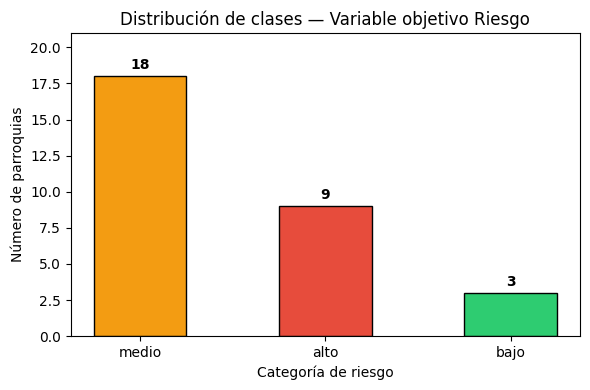


Dataset desbalanceado


In [ ]:
conteo = df_full["riesgo"].value_counts()
total  = len(df_full)

print("Balance de clases: \n")
for clase, n in conteo.items():
    print(f"  {clase:<8}: {n:>3} parroquias ({n/total*100:.1f}%)")

# Visualización
fig, ax = plt.subplots(figsize=(6, 4))
colores = {"bajo": "#2ecc71", "medio": "#f39c12", "alto": "#e74c3c"}
bars = ax.bar(conteo.index, conteo.values,
              color=[colores.get(c, "gray") for c in conteo.index],
              edgecolor="black", width=0.5)
for bar, val in zip(bars, conteo.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha="center", va="bottom", fontweight="bold")
ax.set_title("Distribución de clases — Variable objetivo Riesgo", fontsize=12)
ax.set_xlabel("Categoría de riesgo")
ax.set_ylabel("Número de parroquias")
ax.set_ylim(0, conteo.max() + 3)
plt.tight_layout()
plt.savefig("balance_clases.png", dpi=150)
plt.show()

if conteo.min() / conteo.max() < 0.5:
    print("\nDataset desbalanceado")
else:
    print("\n  Dataset relativamente balanceado. Apto para entrenamiento.")


## 15. Análisis Exploratorio de Datos (EDA) — Estadísticas descriptivas

In [ ]:
print("=" * 100)
print("                     ESTADÍSTICAS DESCRIPTIVAS — VARIABLES PREDICTORAS")
print("=" * 100)

vars_pred = ["precipitacion_mm", "altitud_m", "pendiente_idx",
             "distancia_rio_km", "densidad_pob", "porc_urbano"]
labels    = ["Precipitación (mm/año)", "Altitud (m)", "Pendiente idx",
             "Dist. ríos (km)", "Densidad pob. (hab/km²)", "% Urbano"]

stats = df_full[vars_pred].describe().round(2)
stats.index.name = None
print(stats.to_string())


                     ESTADÍSTICAS DESCRIPTIVAS — VARIABLES PREDICTORAS
       precipitacion_mm  altitud_m  pendiente_idx  distancia_rio_km  densidad_pob  porc_urbano
count             30.00      30.00          30.00             30.00         30.00        30.00
mean            2563.98      59.67           1.50             18.60        141.40        25.41
std              772.23      84.27           2.19             10.96        162.60        33.60
min             1534.72       2.00           0.00              2.21         44.00         0.00
25%             2057.04      13.50           0.30             10.28         59.50         0.00
50%             2406.30      24.50           0.58             17.17         88.00         0.00
75%             2898.80      73.75           1.86             24.98        139.50        52.56
max             4888.68     387.00          10.00             47.38        732.00        95.02


## 16. EDA — Boxplots por variable y nivel de riesgo

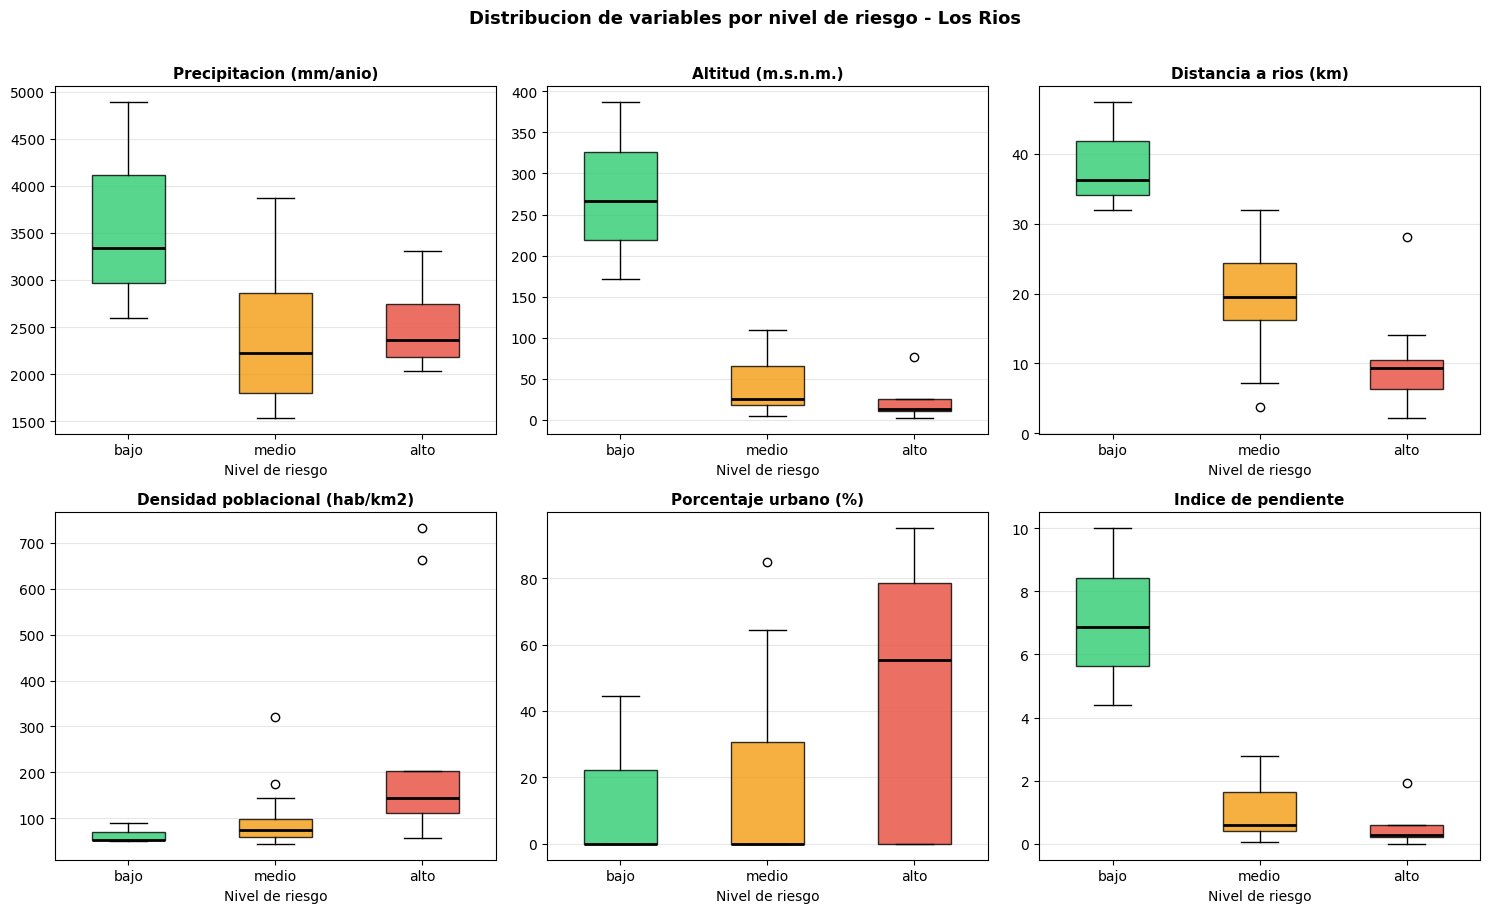


Boxplots guardados correctamente


In [ ]:
vars_plot  = ["precipitacion_mm", "altitud_m", "distancia_rio_km",
              "densidad_pob", "porc_urbano", "pendiente_idx"]
titulos    = ["Precipitacion (mm/anio)", "Altitud (m.s.n.m.)",
              "Distancia a rios (km)", "Densidad poblacional (hab/km2)",
              "Porcentaje urbano (%)", "Indice de pendiente"]
orden_risk = ["bajo", "medio", "alto"]
paleta     = {"bajo": "#2ecc71", "medio": "#f39c12", "alto": "#e74c3c"}
colores_orden = [paleta[r] for r in orden_risk]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (var, titulo) in enumerate(zip(vars_plot, titulos)):
    grupos = [df_full[df_full["riesgo"] == r][var].dropna().values for r in orden_risk]
    bp = axes[i].boxplot(grupos, patch_artist=True, widths=0.5,
                         medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colores_orden):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    axes[i].set_xticks([1, 2, 3])
    axes[i].set_xticklabels(orden_risk)
    axes[i].set_title(titulo, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Nivel de riesgo")
    axes[i].set_ylabel("")
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle("Distribucion de variables por nivel de riesgo - Los Rios",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("boxplots_riesgo.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nBoxplots guardados correctamente")


## 17. EDA — Histogramas de distribución de variables

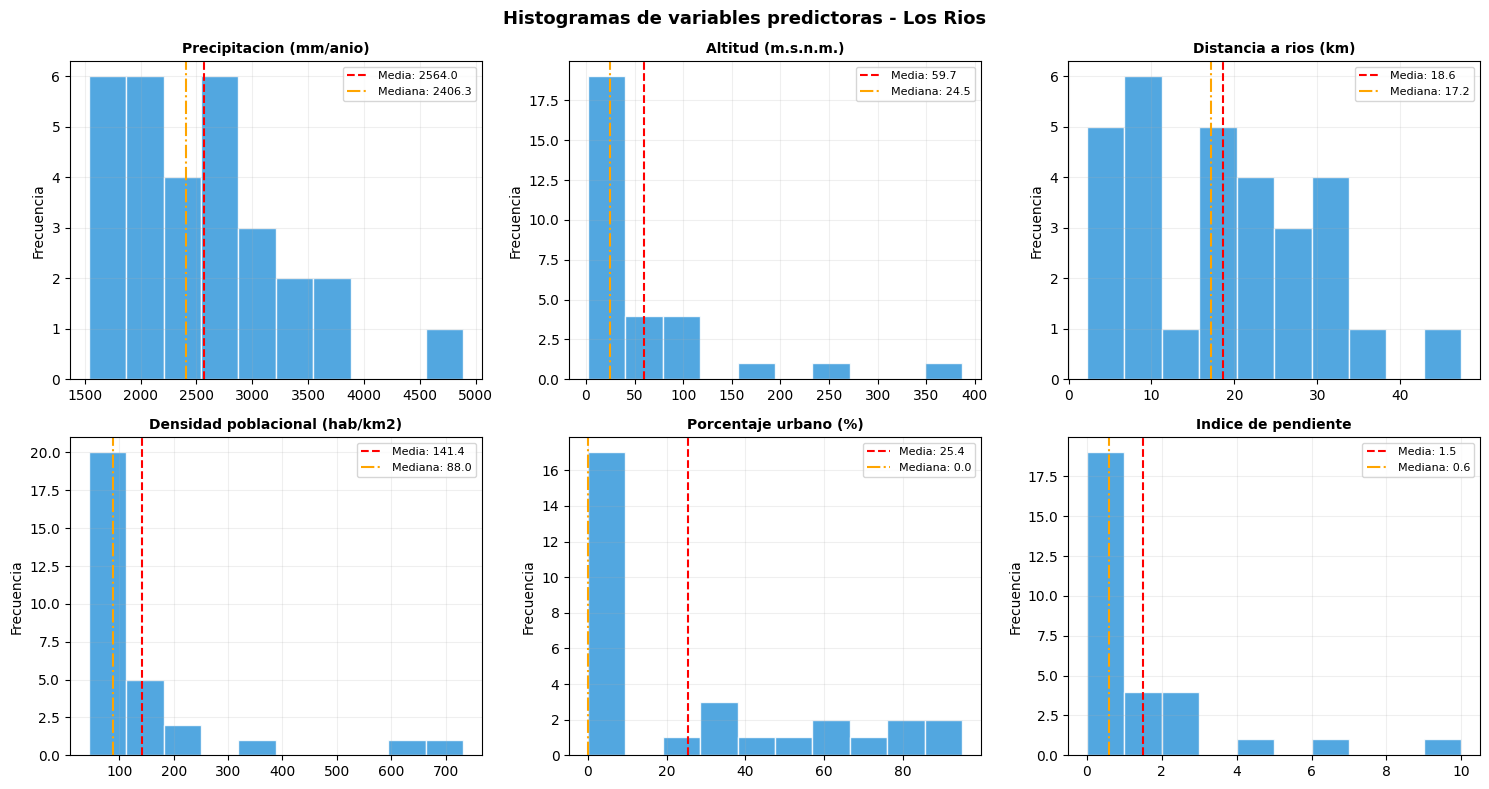


Histogramas guardados


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (var, titulo) in enumerate(zip(vars_plot, titulos)):
    axes[i].hist(df_full[var].dropna(), bins=10, color="#3498db",
                 edgecolor="white", alpha=0.85)
    axes[i].axvline(df_full[var].mean(), color="red", linestyle="--",
                    linewidth=1.5, label=f"Media: {df_full[var].mean():.1f}")
    axes[i].axvline(df_full[var].median(), color="orange", linestyle="-.",
                    linewidth=1.5, label=f"Mediana: {df_full[var].median():.1f}")
    axes[i].set_title(titulo, fontsize=10, fontweight="bold")
    axes[i].set_ylabel("Frecuencia")
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.2)

plt.suptitle("Histogramas de variables predictoras - Los Rios",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("histogramas.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nHistogramas guardados")


## 18. EDA — Mapa de calor de correlaciones

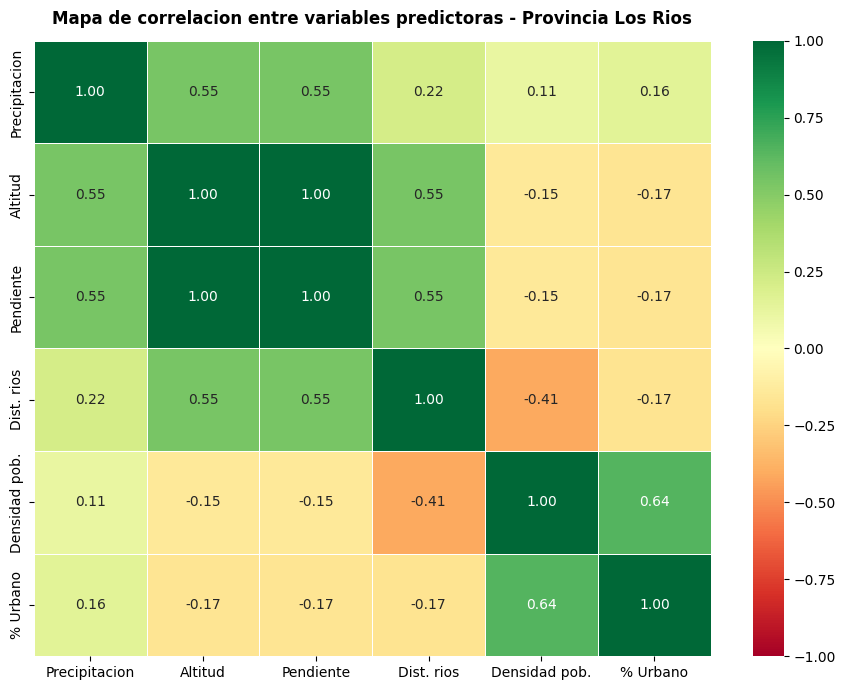


Heatmap guardado


In [ ]:
vars_corr = ["precipitacion_mm", "altitud_m", "pendiente_idx",
             "distancia_rio_km", "densidad_pob", "porc_urbano"]
nombres   = ["Precipitacion", "Altitud", "Pendiente",
             "Dist. rios", "Densidad pob.", "% Urbano"]

corr = df_full[vars_corr].corr()
corr.columns = nombres
corr.index   = nombres

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 10})
ax.set_title("Mapa de correlacion entre variables predictoras"
             " - Provincia Los Rios",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("heatmap_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nHeatmap guardado")


## 19b. EDA Temporal — Descarga de serie diaria de precipitación
**Fuente:** Open-Meteo Archive API — mismas coordenadas ya usadas para la precipitación anual.

Se descarga la serie completa día a día (2019-2023) para construir variables temporales que capturen la estacionalidad y la diferencia entre temporada lluviosa y seca en cada parroquia.

In [ ]:
def get_serie_diaria(lat, lon):
    url = (
        f"https://archive-api.open-meteo.com/v1/archive"
        f"?latitude={lat}&longitude={lon}"
        f"&start_date=2019-01-01&end_date=2023-12-31"
        f"&daily=precipitation_sum&timezone=America%2FGuayaquil"
    )
    try:
        r = requests.get(url, timeout=15)
        data = r.json()
        if "daily" in data:
            return pd.DataFrame({
                "fecha": pd.to_datetime(data["daily"]["time"]),
                "precipitacion_diaria_mm": data["daily"]["precipitation_sum"]
            })
    except:
        pass
    return None

# Descargar serie diaria para todas las parroquias
registros_temporales = []

for _, row in df.iterrows():
    serie = get_serie_diaria(row["latitud"], row["longitud"])
    if serie is not None:
        serie["parroquia"]  = row["DPA_DESPAR"]
        serie["codigo_dpa"] = row["DPA_PARROQ"]
        registros_temporales.append(serie)
    print(f"  {row['DPA_DESPAR']:<35} OK")
    time.sleep(0.5)

df_temporal = pd.concat(registros_temporales, ignore_index=True)

# Limpiar nulos (dias sin dato se reemplazan por 0)
df_temporal["precipitacion_diaria_mm"] = pd.to_numeric(
    df_temporal["precipitacion_diaria_mm"], errors="coerce"
).fillna(0)

# Columnas de tiempo
df_temporal["anio"] = df_temporal["fecha"].dt.year
df_temporal["mes"]  = df_temporal["fecha"].dt.month

print(f"\n✓ Serie temporal lista: {len(df_temporal):,} registros diarios")
print(f"  Parroquias: {df_temporal['parroquia'].nunique()}")
print(f"  Período: {df_temporal['fecha'].min().date()} → {df_temporal['fecha'].max().date()}")

  BABAHOYO                            OK
  CARACOL                             OK
  FEBRES CORDERO (LAS JUNTAS)         OK
  PIMOCHA                             OK
  LA UNION                            OK
  BABA                                OK
  GUARE                               OK
  ISLA DE BEJUCAL                     OK
  MONTALVO                            OK
  PUEBLOVIEJO                         OK
  PUERTO PECHICHE                     OK
  SAN JUAN                            OK
  QUEVEDO                             OK
  SAN CARLOS                          OK
  LA ESPERANZA                        OK
  CATARAMA                            OK
  RICAURTE                            OK
  VENTANAS                            OK
  ZAPOTAL                             OK
  VINCES                              OK
  ANTONIO SOTOMAYOR (CAB. EN PLAYAS DE VINCES) OK
  PALENQUE                            OK
  SAN JACINTO DE BUENA FE             OK
  PATRICIA PILAR                      OK
  VALEN

## 19c. EDA Temporal — Serie de precipitación con promedio móvil

El promedio móvil de 30 días suaviza los picos diarios y permite ver la **estacionalidad** de la lluvia en la provincia: temporada lluviosa (enero-mayo) vs. temporada seca (junio-diciembre). Esto confirma que la variable precipitación tiene un patrón temporal marcado que justifica el uso de umbrales estacionales en la variable objetivo.

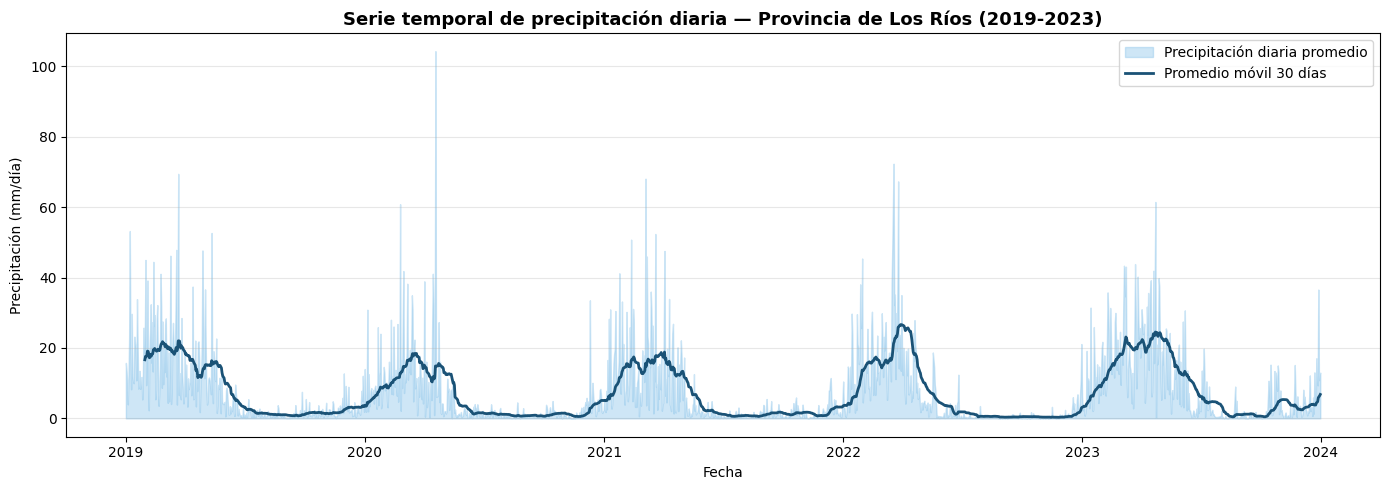

In [ ]:
# Promedio diario de toda la provincia (promedio de las 30 parroquias)
df_prov = (
    df_temporal
    .groupby("fecha")["precipitacion_diaria_mm"]
    .mean()
    .reset_index()
)
df_prov.columns = ["fecha", "precip_prom_diaria"]

# Promedio movil de 30 dias
df_prov["promedio_movil_30d"] = df_prov["precip_prom_diaria"].rolling(30).mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df_prov["fecha"], df_prov["precip_prom_diaria"],
                color="#85C1E9", alpha=0.4, label="Precipitación diaria promedio")
ax.plot(df_prov["fecha"], df_prov["promedio_movil_30d"],
        color="#1A5276", linewidth=2, label="Promedio móvil 30 días")

ax.set_title("Serie temporal de precipitación diaria — Provincia de Los Ríos (2019-2023)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precipitación (mm/día)")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 19d. EDA Temporal — Heatmap mensual y variable derivada temporal

Se construye la **variable temporal derivada** `ratio_lluviosa_seca`: el cociente entre la precipitación promedio de la temporada lluviosa (enero-mayo) y la seca (junio-diciembre) para cada parroquia. Un ratio alto indica mayor vulnerabilidad estacional a inundaciones.

Esta variable captura información que el promedio anual no captura y se agrega al dataset final.

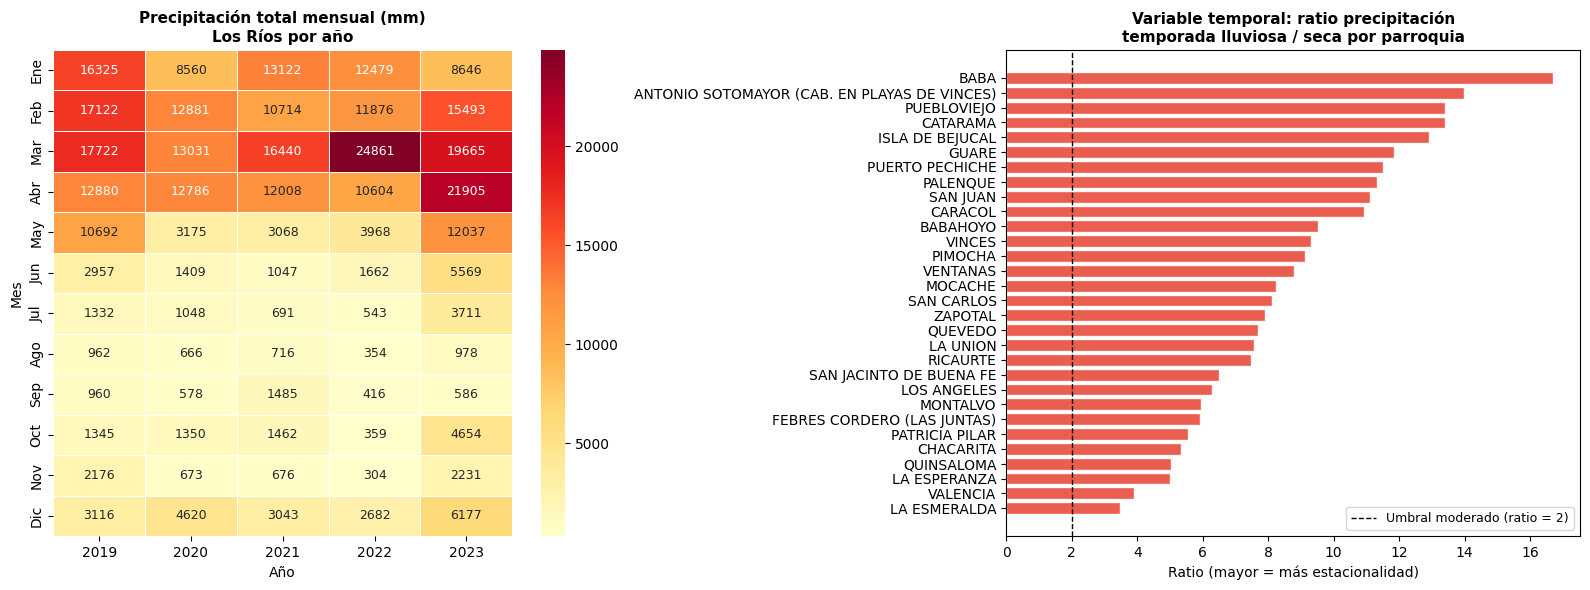

✓ Variable ratio_lluviosa_seca agregada al dataset
                                      DPA_DESPAR  precipitacion_mm  ratio_lluviosa_seca
0                                       BABAHOYO           2747.76                 9.53
1                                        CARACOL           2118.30                10.94
2                    FEBRES CORDERO (LAS JUNTAS)           1783.38                 5.91
3                                        PIMOCHA           2359.90                 9.11
4                                       LA UNION           1534.72                 7.56
5                                           BABA           1702.48                16.69
6                                          GUARE           2184.90                11.83
7                                ISLA DE BEJUCAL           1551.34                12.91
8                                       MONTALVO           1670.46                 5.96
9                                    PUEBLOVIEJO           2057.04   

In [ ]:
# ---- Heatmap precipitacion total por mes x año (toda la provincia) ----
mensual_prov = (
    df_temporal
    .groupby(["anio","mes"])["precipitacion_diaria_mm"]
    .sum()
    .reset_index()
)
mensual_prov.columns = ["anio", "mes", "precip_mensual_mm"]

pivot = mensual_prov.pivot(index="mes", columns="anio", values="precip_mensual_mm")
pivot.index = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=axes[0], annot_kws={"size": 9})
axes[0].set_title("Precipitación total mensual (mm)\nLos Ríos por año",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Mes")

# ---- Variable temporal derivada: ratio temporada lluviosa / seca ----
mensual_parr = (
    df_temporal
    .groupby(["parroquia","anio","mes"])["precipitacion_diaria_mm"]
    .sum()
    .reset_index()
)
mensual_parr.columns = ["parroquia","anio","mes","precip_mensual_mm"]

# Meses 1-5 = lluviosa, 6-12 = seca (patron climatico de la Costa ecuatoriana)
mensual_parr["temporada"] = mensual_parr["mes"].apply(
    lambda m: "lluviosa" if m in [1, 2, 3, 4, 5] else "seca"
)

pivot_temp = (
    mensual_parr
    .groupby(["parroquia","temporada"])["precip_mensual_mm"]
    .mean()
    .unstack()
)
pivot_temp["ratio_lluviosa_seca"] = (pivot_temp["lluviosa"] / pivot_temp["seca"]).round(2)
pivot_temp = pivot_temp.reset_index().sort_values("ratio_lluviosa_seca", ascending=True)

colores_ratio = ["#e74c3c" if v > 3 else "#f39c12" if v > 2 else "#2ecc71"
                 for v in pivot_temp["ratio_lluviosa_seca"]]

axes[1].barh(pivot_temp["parroquia"], pivot_temp["ratio_lluviosa_seca"],
             color=colores_ratio, edgecolor="white", alpha=0.9)
axes[1].axvline(2, color="black", linestyle="--", linewidth=1,
                label="Umbral moderado (ratio = 2)")
axes[1].set_title("Variable temporal: ratio precipitación\ntemporada lluviosa / seca por parroquia",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Ratio (mayor = más estacionalidad)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Agregar la variable temporal al dataset principal
df_full = df_full.merge(
    pivot_temp[["parroquia","ratio_lluviosa_seca"]],
    left_on="DPA_DESPAR", right_on="parroquia", how="left"
).drop(columns=["parroquia"])

print("✓ Variable ratio_lluviosa_seca agregada al dataset")
print(df_full[["DPA_DESPAR","precipitacion_mm","ratio_lluviosa_seca"]].to_string())

In [ ]:
# Verificación: ratio_lluviosa_seca no debe tener nulos antes de modelar
nulos_ratio = df_full["ratio_lluviosa_seca"].isnull().sum()
print(f"Nulos en ratio_lluviosa_seca: {nulos_ratio}")
if nulos_ratio > 0:
    mediana_ratio = df_full["ratio_lluviosa_seca"].median()
    df_full["ratio_lluviosa_seca"] = df_full["ratio_lluviosa_seca"].fillna(mediana_ratio)
    print(f"  → Imputado con mediana ({mediana_ratio:.2f})")
else:
    print("Merge exitoso para todas las parroquias.")

Nulos en ratio_lluviosa_seca: 0
Merge exitoso para todas las parroquias.


## 19e. EDA — Ranking de precipitacion por parroquia
Se presenta el ranking de precipitacion anual promedio coloreado por nivel de riesgo.


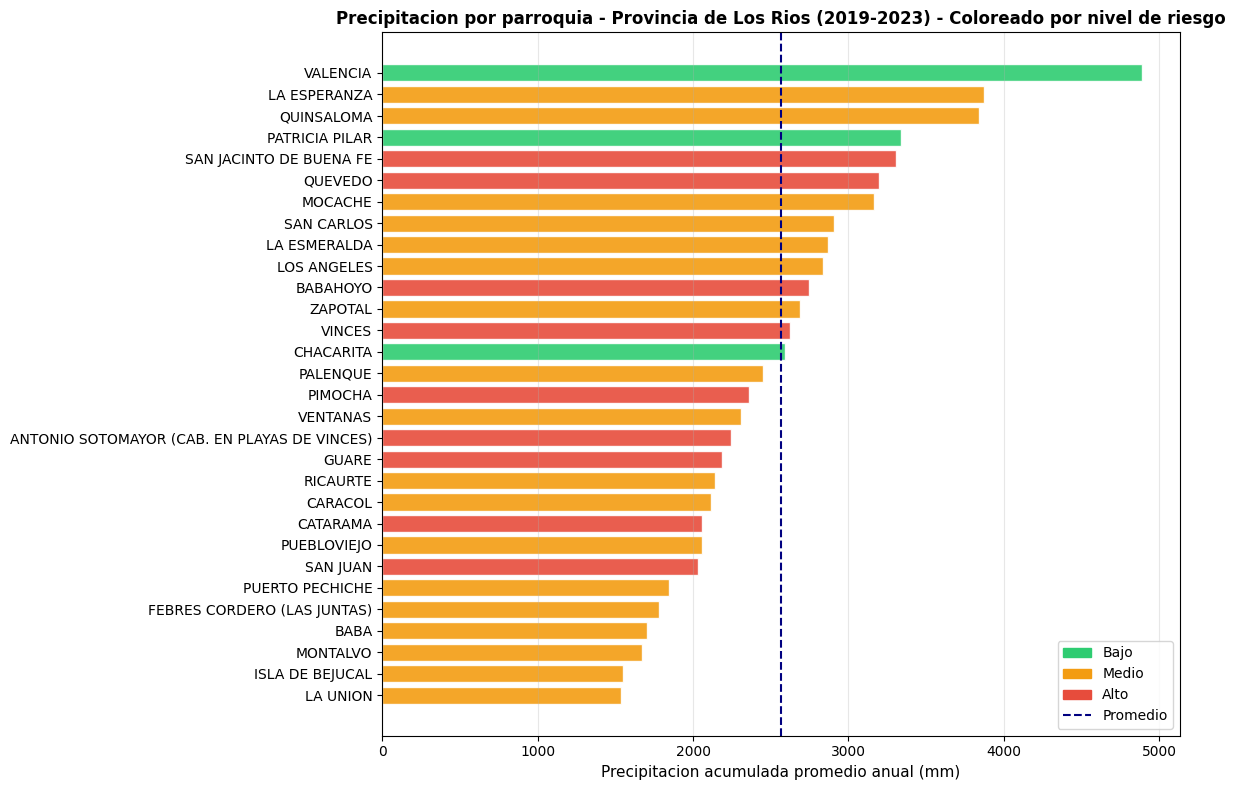

Ranking precipitacion guardado


In [ ]:
# Ordenar parroquias por precipitacion
df_ord = df_full.sort_values("precipitacion_mm", ascending=True).copy()
colores_barra = [paleta.get(r, "gray") for r in df_ord["riesgo"]]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(df_ord["DPA_DESPAR"], df_ord["precipitacion_mm"],
               color=colores_barra, edgecolor="white", alpha=0.9)
ax.axvline(df_full["precipitacion_mm"].mean(), color="navy",
           linestyle="--", linewidth=1.5,
           label=f"Promedio: {df_full['precipitacion_mm'].mean():.0f} mm/anio")

leyenda = [mpatches.Patch(color=c, label=l)
           for l, c in [("Bajo", "#2ecc71"), ("Medio", "#f39c12"), ("Alto", "#e74c3c")]]
leyenda.append(plt.Line2D([0],[0], color="navy", linestyle="--", label="Promedio"))
ax.legend(handles=leyenda, loc="lower right")

ax.set_xlabel("Precipitacion acumulada promedio anual (mm)", fontsize=11)
ax.set_title("Precipitacion por parroquia - Provincia de Los Rios (2019-2023)"
             " - Coloreado por nivel de riesgo",
             fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("precipitacion_ranking.png", dpi=150, bbox_inches="tight")
plt.show()
print("Ranking precipitacion guardado")


## 20. EDA — Relación altitud vs precipitación por nivel de riesgo

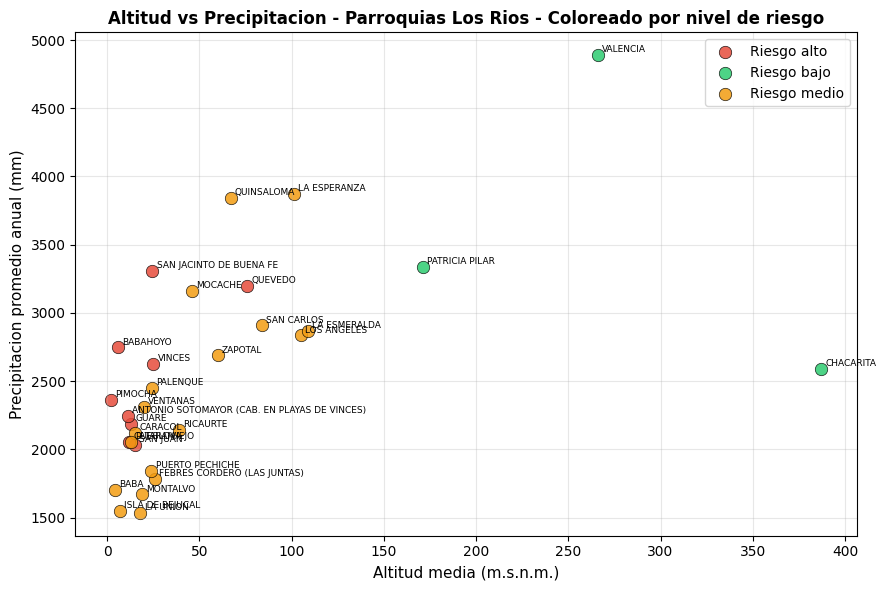

Scatter guardado


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

for riesgo_nivel, grupo in df_full.groupby("riesgo"):
    ax.scatter(grupo["altitud_m"], grupo["precipitacion_mm"],
               c=paleta[riesgo_nivel], label=f"Riesgo {riesgo_nivel}",
               s=80, edgecolors="black", linewidths=0.5, alpha=0.85)
    for _, row in grupo.iterrows():
        ax.annotate(row["DPA_DESPAR"],
                    (row["altitud_m"], row["precipitacion_mm"]),
                    fontsize=6.5, ha="left", xytext=(3, 2),
                    textcoords="offset points")

ax.set_xlabel("Altitud media (m.s.n.m.)", fontsize=11)
ax.set_ylabel("Precipitacion promedio anual (mm)", fontsize=11)
ax.set_title("Altitud vs Precipitacion - Parroquias Los Rios"
             " - Coloreado por nivel de riesgo",
             fontsize=12, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("scatter_altitud_precipitacion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Scatter guardado")


## 21. Dataset final — Exportación a CSV

In [ ]:
# Codificar variable objetivo para los modelos
label_map  = {"bajo": 0, "medio": 1, "alto": 2}
df_full["riesgo_cod"] = df_full["riesgo"].map(label_map)

# Seleccionar columnas finales
cols_finales = [
    "DPA_PARROQ", "DPA_DESPAR", "DPA_DESCAN",
    "precipitacion_mm", "altitud_m", "pendiente_idx",
    "distancia_rio_km", "densidad_pob", "porc_urbano",
    "ratio_lluviosa_seca",
    "riesgo", "riesgo_cod"
]

df_final = df_full[cols_finales].copy()
df_final.columns = [
    "codigo_parroquia", "parroquia", "canton",
    "precipitacion_mm", "altitud_m", "pendiente_idx",
    "distancia_rio_km", "densidad_pob", "porc_urbano",
    "ratio_lluviosa_seca",
    "riesgo", "riesgo_cod"
]

df_final.to_csv("dataset_losrios_final.csv", index=False)

print("✓ Dataset final exportado: dataset_losrios_final.csv")
print(f"  Shape: {df_final.shape}")
print(f"  Nulos totales: {df_final.isnull().sum().sum()}")
print()
print(df_final.to_string())

✓ Dataset final exportado: dataset_losrios_final.csv
  Shape: (30, 12)
  Nulos totales: 0

   codigo_parroquia                                     parroquia       canton  precipitacion_mm  altitud_m  pendiente_idx  distancia_rio_km  densidad_pob  porc_urbano  ratio_lluviosa_seca riesgo  riesgo_cod
0            120150                                      BABAHOYO     BABAHOYO           2747.76       6.00           0.10              6.37        662.00        87.70                 9.53   alto           2
1            120152                                       CARACOL     BABAHOYO           2118.30      15.00           0.34              3.84         57.00         0.00                10.94  medio           1
2            120153                   FEBRES CORDERO (LAS JUNTAS)     BABAHOYO           1783.38      26.00           0.62             30.59         55.00         0.00                 5.91  medio           1
3            120154                                       PIMOCHA     BABAHOY

## 22. Resumen de variables y fuentes

| Variable | Tipo | Fuente | Descripcion |
|---|---|---|---|
| `precipitacion_mm` | Predictora | Open-Meteo Archive API | Precipitacion promedio anual 2019-2023 (mm) |
| `altitud_m` | Predictora | Open-Meteo Elevation API | Altitud media del centroide (m.s.n.m.) |
| `pendiente_idx` | **Derivada** | Calculada desde altitud | Indice de pendiente relativa [0-10] |
| `distancia_rio_km` | Predictora | Coordenadas ríos principales / Haversine| Distancia minima a rios principales (km) |
| `densidad_pob` | Predictora | INEC Censo 2022 | Habitantes por km2 |
| `porc_urbano` | Predictora | INEC Censo 2022 / Redatam | Porcentaje de poblacion urbana (%) |
| `ratio_lluviosa_seca` | **Derivada temporal** | Open-Meteo serie diaria | Cociente precip. temporada lluviosa / seca por parroquia |
| `riesgo` | **Objetivo** | Construida multicriterio | Categoria: bajo / medio / alto |

### Criterios de la variable objetivo
El riesgo de inundacion se determina por puntuacion (score) acumulada:
- **Precipitacion > 2000 mm/anio** → zonas de alta pluviosidad
- **Altitud < 30 m.s.n.m.** → llanuras de inundacion historicas
- **Distancia < 20 km a rios** → exposicion a desbordamientos
- **Densidad > 100 hab/km2** → mayor vulnerabilidad social
- **Pendiente baja** → escasa capacidad de drenaje natural
- **Ratio lluviosa/seca alto** → mayor variabilidad estacional de lluvias

**Referencia:** SNGRE — Los Rios es la provincia con mayor frecuencia historica
de inundaciones en Ecuador (temporadas lluviosas 2019-2023).
Criterios alineados con el Marco de Sendai para Reduccion del Riesgo de Desastres 2015-2030.


---
# Modelado, Optimización y Evaluación
El `df_full` y el `df_final` ya están en memoria — no es necesario recargar archivos.


## 23. Instalación de librerías adicionales para modelado

In [ ]:
!pip install scikit-learn joblib -q

import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc
)

print("Librerias de modelado cargadas correctamente")


Librerias de modelado cargadas correctamente


## 24. Preparación de variables para modelado
Se usa el DataFrame `df_final` generado.  
Se seleccionan las **7 variables predictoras** y se codifica la variable objetivo  
con `LabelEncoder`. Se usa `class_weight="balanced"` en todos los modelos  
porque el dataset de 30 parroquias puede tener clases desbalanceadas.


In [ ]:
FEATURES = [
    "precipitacion_mm", "altitud_m", "pendiente_idx",
    "distancia_rio_km", "densidad_pob", "porc_urbano",
    "ratio_lluviosa_seca"
]

X = df_final[FEATURES]
y = df_final["riesgo"]

# Codificar etiquetas en orden logico de riesgo
le = LabelEncoder()
le.fit(["bajo", "medio", "alto"])
y_enc = le.transform(y)
clases = le.classes_

print("Variables predictoras:", FEATURES)
print("Clases codificadas:", {str(k): int(v) for k, v in zip(clases, le.transform(clases))})
print(f"\nDistribucion: { {str(clases[k]): int(v) for k, v in zip(*np.unique(y_enc, return_counts=True))} }")


Variables predictoras: ['precipitacion_mm', 'altitud_m', 'pendiente_idx', 'distancia_rio_km', 'densidad_pob', 'porc_urbano', 'ratio_lluviosa_seca']
Clases codificadas: {'alto': 0, 'bajo': 1, 'medio': 2}

Distribucion: {'alto': 9, 'bajo': 3, 'medio': 18}


## 25. División train/test
Se usa 75% para entrenamiento y 25% para prueba.  
Se aplica `stratify` para mantener la proporción de clases en ambos conjuntos.


In [ ]:
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
    )
    print("Split estratificado aplicado")
except ValueError:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.25, random_state=42
    )
    print("Split sin estratificar (alguna clase tiene muy pocos ejemplos)")

# Escalar: necesario para Regresion Logistica
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrain: {len(X_train)} parroquias | Test: {len(X_test)} parroquias")
print(f"Distribucion train: { {str(clases[k]): int(v) for k, v in zip(*np.unique(y_train, return_counts=True))} }")
print(f"Distribucion test:  { {str(clases[k]): int(v) for k, v in zip(*np.unique(y_test,  return_counts=True))} }")


Split estratificado aplicado

Train: 22 parroquias | Test: 8 parroquias
Distribucion train: {'alto': 7, 'bajo': 2, 'medio': 13}
Distribucion test:  {'alto': 2, 'bajo': 1, 'medio': 5}


## 26. Modelo base: Regresión Logística
Primer modelo de referencia. Se entrena sobre las variables escaladas.  
Se usa `class_weight="balanced"` para compensar el posible desbalance de clases.


In [ ]:
rl = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
rl.fit(X_train_sc, y_train)

y_pred_rl = rl.predict(X_test_sc)
y_prob_rl = rl.predict_proba(X_test_sc)

print("=" * 55)
print("REGRESION LOGISTICA - Reporte de clasificacion")
print("=" * 55)
print(classification_report(y_test, y_pred_rl, target_names=clases, zero_division=0))


REGRESION LOGISTICA - Reporte de clasificacion
              precision    recall  f1-score   support

        alto       0.67      1.00      0.80         2
        bajo       1.00      1.00      1.00         1
       medio       1.00      0.80      0.89         5

    accuracy                           0.88         8
   macro avg       0.89      0.93      0.90         8
weighted avg       0.92      0.88      0.88         8



## 27. Árbol de Decisión
Segundo modelo base. No requiere escalado.  
Permite interpretar las decisiones de clasificación a través del árbol.


In [ ]:
dt = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)

print("=" * 55)
print("ARBOL DE DECISION - Reporte de clasificacion")
print("=" * 55)
print(classification_report(y_test, y_pred_dt, target_names=clases, zero_division=0))

# Importancia de variables
imp_dt = pd.Series(dt.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\nImportancia de variables (DT):")
print(imp_dt.round(3))


ARBOL DE DECISION - Reporte de clasificacion
              precision    recall  f1-score   support

        alto       0.00      0.00      0.00         2
        bajo       1.00      1.00      1.00         1
       medio       0.71      1.00      0.83         5

    accuracy                           0.75         8
   macro avg       0.57      0.67      0.61         8
weighted avg       0.57      0.75      0.65         8


Importancia de variables (DT):
altitud_m             0.50
pendiente_idx         0.21
porc_urbano           0.16
distancia_rio_km      0.07
ratio_lluviosa_seca   0.06
precipitacion_mm      0.00
densidad_pob          0.00
dtype: float64


## 28. Modelo Ensamble: VotingClassifier (RL + DT + Random Forest)
Combina los tres modelos con votacion suave (`voting="soft"`):  
cada modelo aporta sus probabilidades y se promedia el resultado.  
La Regresion Logistica se incluye dentro de un Pipeline con scaler propio.


In [ ]:
# RL necesita scaler propio dentro del pipeline del ensamble
rl_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rl", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

dt_v = DecisionTreeClassifier(class_weight="balanced", random_state=42)
rf_v = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)

ensemble = VotingClassifier(
    estimators=[("rl", rl_pipe), ("dt", dt_v), ("rf", rf_v)],
    voting="soft"
)
ensemble.fit(X_train, y_train)

y_pred_ens = ensemble.predict(X_test)
y_prob_ens = ensemble.predict_proba(X_test)

print("=" * 55)
print("ENSAMBLE (RL + DT + RF) - Reporte de clasificacion")
print("=" * 55)
print(classification_report(y_test, y_pred_ens, target_names=clases, zero_division=0))


ENSAMBLE (RL + DT + RF) - Reporte de clasificacion
              precision    recall  f1-score   support

        alto       0.00      0.00      0.00         2
        bajo       1.00      1.00      1.00         1
       medio       0.71      1.00      0.83         5

    accuracy                           0.75         8
   macro avg       0.57      0.67      0.61         8
weighted avg       0.57      0.75      0.65         8



## 29. Optimización de hiperparámetros: GridSearchCV sobre Random Forest
Se busca la mejor combinacion de hiperparametros usando validacion cruzada  
estratificada (2 folds). La metrica de optimizacion es `f1_macro` porque  
evalua el rendimiento en todas las clases por igual, importante cuando  
la clase "alto" es minoritaria pero critica.


In [ ]:
param_grid = {
    "n_estimators":      [50, 100, 200],
    "max_depth":         [None, 5, 10],
    "min_samples_split": [2, 5]
}

cv_folds = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid,
    cv=cv_folds,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

rf_opt = grid.best_estimator_
y_pred_opt = rf_opt.predict(X_test)
y_prob_opt  = rf_opt.predict_proba(X_test)

print("Mejores hiperparametros encontrados:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"  F1-macro (CV): {grid.best_score_:.3f}")
print()
print("=" * 55)
print("RF OPTIMIZADO - Reporte de clasificacion")
print("=" * 55)
print(classification_report(y_test, y_pred_opt, target_names=clases, zero_division=0))


Fitting 2 folds for each of 18 candidates, totalling 36 fits
Mejores hiperparametros encontrados:
  max_depth: None
  min_samples_split: 5
  n_estimators: 50
  F1-macro (CV): 0.676

RF OPTIMIZADO - Reporte de clasificacion
              precision    recall  f1-score   support

        alto       0.50      1.00      0.67         2
        bajo       1.00      1.00      1.00         1
       medio       1.00      0.60      0.75         5

    accuracy                           0.75         8
   macro avg       0.83      0.87      0.81         8
weighted avg       0.88      0.75      0.76         8



## 30. Matrices de confusión — Comparación de modelos

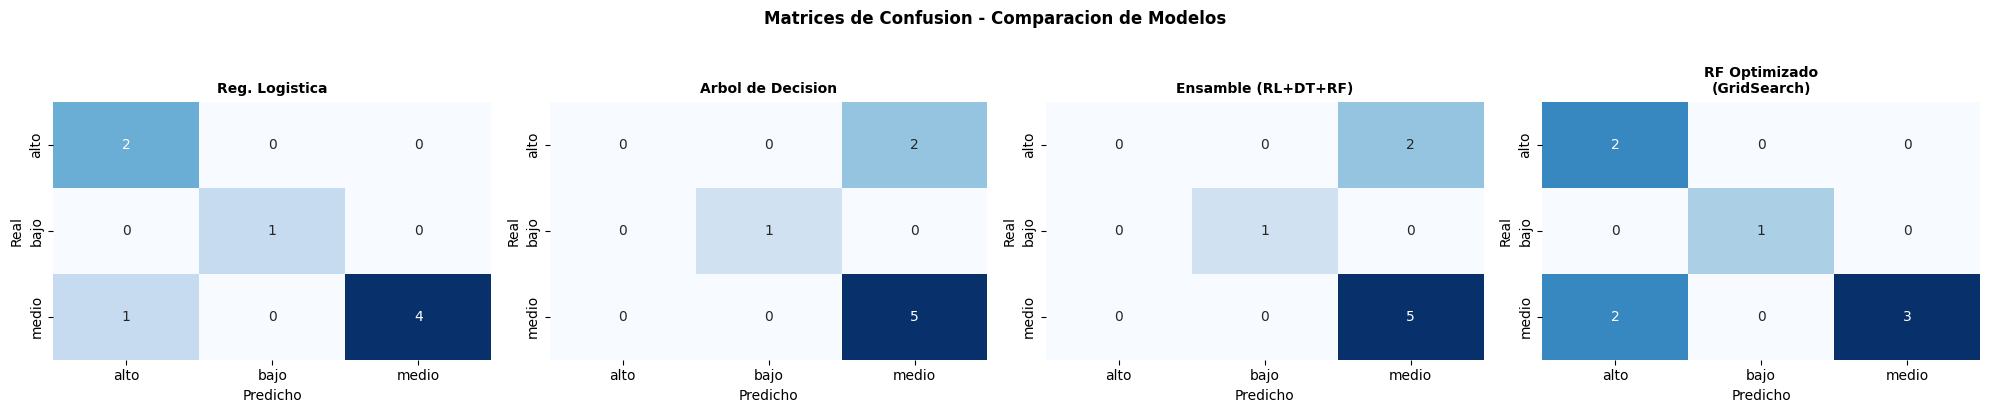

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

modelos_cm = [
    ("Reg. Logistica",        y_pred_rl),
    ("Arbol de Decision",     y_pred_dt),
    ("Ensamble (RL+DT+RF)",   y_pred_ens),
    ("RF Optimizado\n(GridSearch)", y_pred_opt)
]

for ax, (titulo, y_pred) in zip(axes, modelos_cm):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=clases, yticklabels=clases, cbar=False)
    ax.set_title(titulo, fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.suptitle("Matrices de Confusion - Comparacion de Modelos",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
print("=" * 60)
print("ANÁLISIS DE MATRICES DE CONFUSIÓN")
print("=" * 60)

for nombre, y_pred in [
    ("Reg. Logística",        y_pred_rl),
    ("Árbol de Decisión",     y_pred_dt),
    ("Ensamble (RL+DT+RF)",   y_pred_ens),
    ("RF Optimizado",         y_pred_opt),
]:
    cm = confusion_matrix(y_test, y_pred)
    idx_alto = list(clases).index("alto")
    fn_alto = cm[idx_alto, :].sum() - cm[idx_alto, idx_alto]
    fp_alto = cm[:, idx_alto].sum() - cm[idx_alto, idx_alto]
    correctas = int(np.trace(cm))
    print(f"\n{nombre}")
    print(f"   Falsos negativos en \'alto\': {fn_alto}  (parroquias de alto riesgo clasificadas incorrectamente)")
    print(f"   Falsos positivos en \'alto\': {fp_alto}  (parroquias de otro riesgo clasificadas como alto)")
    print(f"   Clasificaciones correctas: {correctas}/{len(y_test)}")

print("\n→ En gestión de riesgo, priorizar el modelo con menos falsos negativos en \'alto\'.")

ANÁLISIS DE MATRICES DE CONFUSIÓN

Reg. Logística
   Falsos negativos en 'alto': 0  (parroquias de alto riesgo clasificadas incorrectamente)
   Falsos positivos en 'alto': 1  (parroquias de otro riesgo clasificadas como alto)
   Clasificaciones correctas: 7/8

Árbol de Decisión
   Falsos negativos en 'alto': 2  (parroquias de alto riesgo clasificadas incorrectamente)
   Falsos positivos en 'alto': 0  (parroquias de otro riesgo clasificadas como alto)
   Clasificaciones correctas: 6/8

Ensamble (RL+DT+RF)
   Falsos negativos en 'alto': 2  (parroquias de alto riesgo clasificadas incorrectamente)
   Falsos positivos en 'alto': 0  (parroquias de otro riesgo clasificadas como alto)
   Clasificaciones correctas: 6/8

RF Optimizado
   Falsos negativos en 'alto': 0  (parroquias de alto riesgo clasificadas incorrectamente)
   Falsos positivos en 'alto': 2  (parroquias de otro riesgo clasificadas como alto)
   Clasificaciones correctas: 6/8

→ En gestión de riesgo, priorizar el modelo con menos 

## 31. Tabla comparativa de métricas

**Por que Recall es la metrica prioritaria:**  
En gestion de riesgo de inundacion, un **falso negativo** (clasificar como "bajo riesgo"  
una parroquia de "alto riesgo") tiene consecuencias mucho mas graves que un falso positivo.  
Una parroquia de alto riesgo no identificada queda sin medidas de proteccion, poniendo  
en peligro a su poblacion. Por eso, maximizar el **Recall** es la prioridad sobre la Precision.


In [ ]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

resultados = []
for nombre, y_pred, y_prob in [
    ("Reg. Logistica",      y_pred_rl,  y_prob_rl),
    ("Arbol de Decision",   y_pred_dt,  y_prob_dt),
    ("Ensamble (RL+DT+RF)", y_pred_ens, y_prob_ens),
    ("RF Optimizado",       y_pred_opt, y_prob_opt),
]:
    try:
        auc_val = roc_auc_score(y_test_bin, y_prob, multi_class="ovr", average="macro")
    except:
        auc_val = float("nan")
    resultados.append({
        "Modelo":    nombre,
        "Precision": round(precision_score(y_test, y_pred, average="macro", zero_division=0), 3),
        "Recall":    round(recall_score   (y_test, y_pred, average="macro", zero_division=0), 3),
        "F1-score":  round(f1_score       (y_test, y_pred, average="macro", zero_division=0), 3),
        "AUC-ROC":   round(auc_val, 3)
    })

df_resultados = pd.DataFrame(resultados)
idx_mejor = df_resultados["Recall"].idxmax()

print("=" * 60)
print("TABLA COMPARATIVA DE METRICAS (macro-promedio)")
print("=" * 60)
print(df_resultados.to_string(index=False))
print()
print(f"Modelo con mayor Recall: {df_resultados.loc[idx_mejor, 'Modelo']}")
print(f"  Recall: {df_resultados.loc[idx_mejor, 'Recall']}")


TABLA COMPARATIVA DE METRICAS (macro-promedio)
             Modelo  Precision  Recall  F1-score  AUC-ROC
     Reg. Logistica       0.89    0.93      0.90     0.90
  Arbol de Decision       0.57    0.67      0.61     0.72
Ensamble (RL+DT+RF)       0.57    0.67      0.61     0.85
      RF Optimizado       0.83    0.87      0.81     0.81

Modelo con mayor Recall: Reg. Logistica
  Recall: 0.933


## 32. Curvas ROC — Modelo ganador
Se grafican las curvas ROC con estrategia **One-vs-Rest (OvR)**.  
Un AUC cercano a 1.0 indica excelente discriminacion.


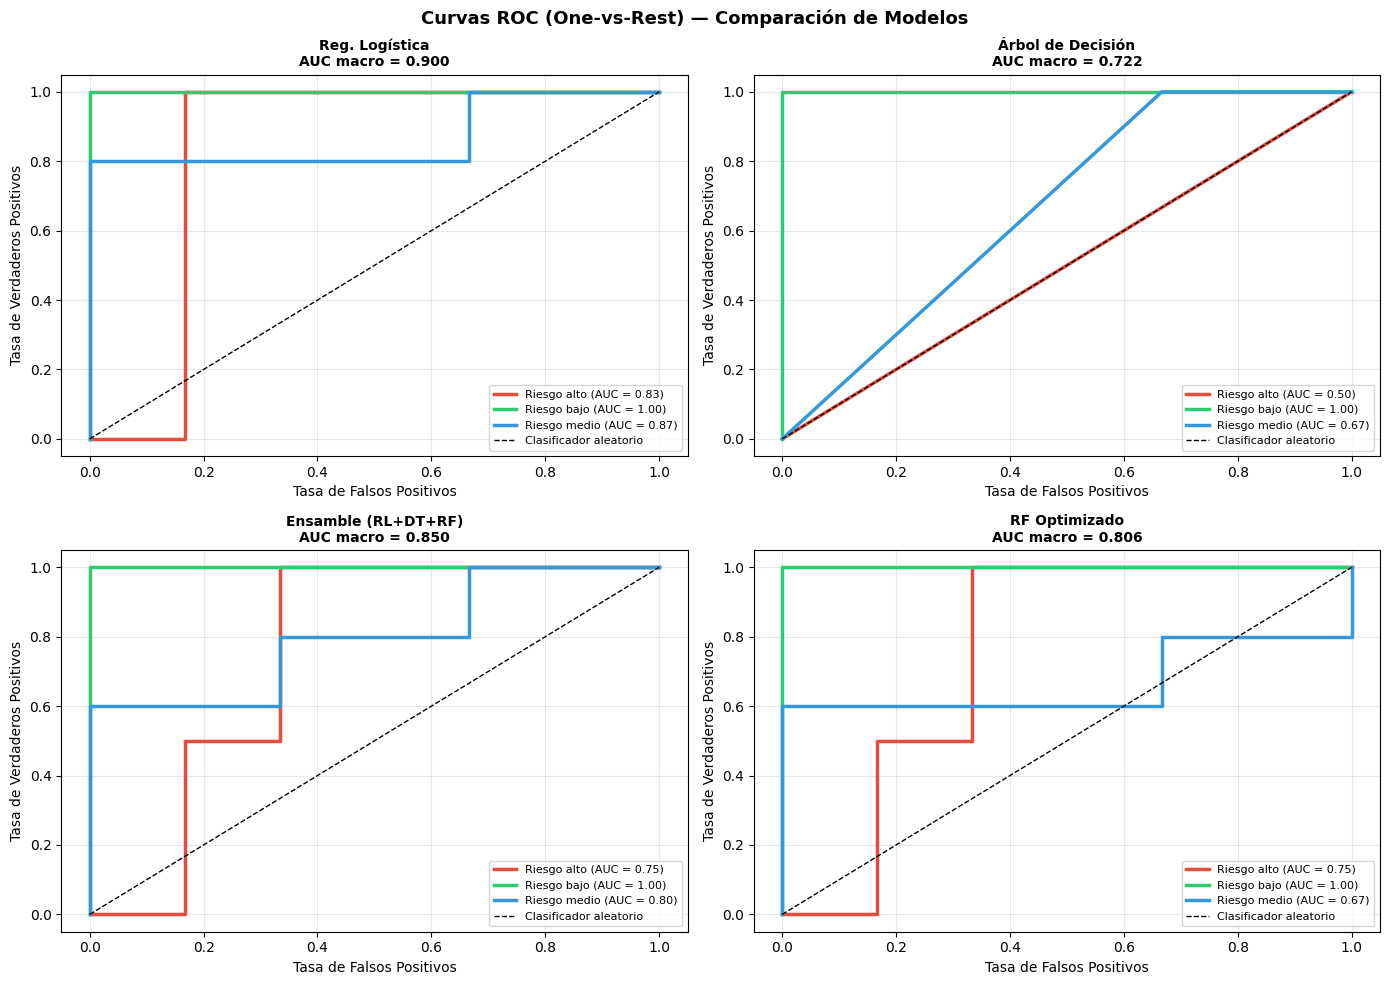

✓ Curvas ROC de los 4 modelos generadas


In [ ]:
# Curvas ROC OvR — comparación de los 4 modelos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

modelos_roc = [
    ("Reg. Logística",        y_prob_rl),
    ("Árbol de Decisión",     y_prob_dt),
    ("Ensamble (RL+DT+RF)",   y_prob_ens),
    ("RF Optimizado",         y_prob_opt),
]
colores_roc = {"alto": "#e74c3c", "bajo": "#2ecc71", "medio": "#3498db"}

for ax, (nombre, y_prob) in zip(axes, modelos_roc):
    auc_vals = []
    for i, clase in enumerate(clases):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        auc_i = auc(fpr, tpr)
        auc_vals.append(auc_i)
        ax.plot(fpr, tpr, color=colores_roc[clase], linewidth=2.5,
                label=f"Riesgo {clase} (AUC = {auc_i:.2f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Clasificador aleatorio")
    ax.set_title(f"{nombre}\nAUC macro = {sum(auc_vals)/len(clases):.3f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Tasa de Falsos Positivos")
    ax.set_ylabel("Tasa de Verdaderos Positivos")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Curvas ROC (One-vs-Rest) — Comparación de Modelos",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("roc_comparativo.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Curvas ROC de los 4 modelos generadas")

## 33. Importancia de variables — RF Optimizado

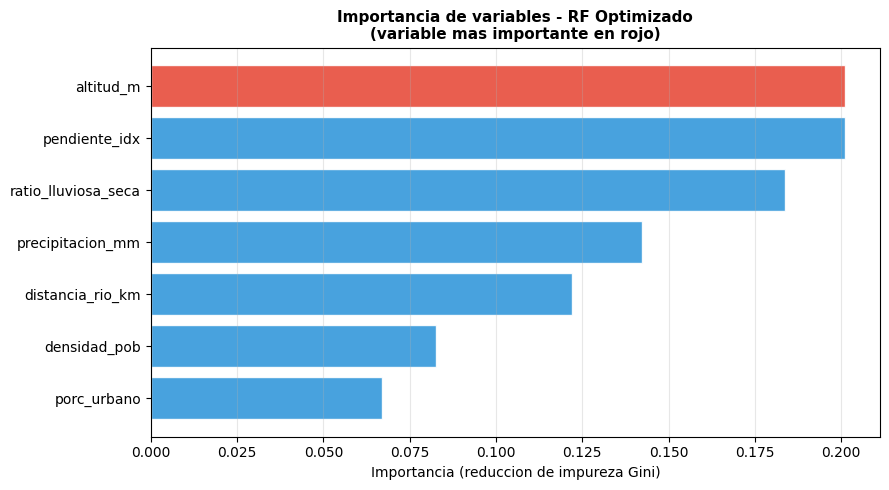

Variables ordenadas por importancia:
  altitud_m                 0.2012
  pendiente_idx             0.2011
  ratio_lluviosa_seca       0.1837
  precipitacion_mm          0.1424
  distancia_rio_km          0.1220
  densidad_pob              0.0826
  porc_urbano               0.0670


In [ ]:
importancias = pd.Series(
    rf_opt.feature_importances_, index=FEATURES
).sort_values(ascending=True)

colores_imp = ["#e74c3c" if v == importancias.max() else "#3498db"
               for v in importancias]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importancias.index, importancias.values,
        color=colores_imp, edgecolor="white", alpha=0.9)
ax.set_title("Importancia de variables - RF Optimizado\n(variable mas importante en rojo)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Importancia (reduccion de impureza Gini)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Variables ordenadas por importancia:")
for var, val in importancias.sort_values(ascending=False).items():
    print(f"  {var:<25} {val:.4f}")


## 34. Exportación del modelo y archivos para la aplicación web
Se guardan los archivos que la **Pareja C** necesita para el backend Flask:
- `modelo.pkl` — modelo entrenado listo para `predict()`
- `scaler.pkl` — scaler ajustado (para normalizar inputs nuevos)
- `label_encoder.pkl` — convierte prediccion numerica a texto
- `predicciones_parroquias.csv` — predicciones para el mapa interactivo


In [ ]:
joblib.dump(rl, "modelo.pkl")           # <-- antes: joblib.dump(rf_opt, "modelo.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le,     "label_encoder.pkl")

print("modelo.pkl guardado (Regresion Logistica)")
print("scaler.pkl guardado")
print("label_encoder.pkl guardado")

# CSV de predicciones para el mapa (Pareja C)
X_all     = df_final[FEATURES]
X_all_sc  = scaler.transform(X_all)     # <-- RL necesita datos escalados, RF no los necesitaba

pred_all  = rl.predict(X_all_sc)        # <-- antes: rf_opt.predict(X_all)
prob_all  = rl.predict_proba(X_all_sc)  # <-- antes: rf_opt.predict_proba(X_all)

df_pred = df_final[["codigo_parroquia", "parroquia", "canton", "riesgo"]].copy()
df_pred["riesgo_pred"] = le.inverse_transform(pred_all)
df_pred["prob_alto"]   = prob_all[:, list(clases).index("alto")].round(3)
df_pred["prob_medio"]  = prob_all[:, list(clases).index("medio")].round(3)
df_pred["prob_bajo"]   = prob_all[:, list(clases).index("bajo")].round(3)
df_pred["score"]       = prob_all.max(axis=1).round(3)

df_pred.to_csv("predicciones_parroquias.csv", index=False)

print("\npredicciones_parroquias.csv guardado (con Regresion Logistica)")
print(f"  Shape: {df_pred.shape}")
print()
print(df_pred.to_string(index=False))


modelo.pkl guardado (Regresion Logistica)
scaler.pkl guardado
label_encoder.pkl guardado

predicciones_parroquias.csv guardado (con Regresion Logistica)
  Shape: (30, 9)

codigo_parroquia                                    parroquia      canton riesgo riesgo_pred  prob_alto  prob_medio  prob_bajo  score
          120150                                     BABAHOYO    BABAHOYO   alto        alto       0.96        0.04       0.00   0.96
          120152                                      CARACOL    BABAHOYO  medio        alto       0.53        0.47       0.00   0.53
          120153                  FEBRES CORDERO (LAS JUNTAS)    BABAHOYO  medio       medio       0.07        0.91       0.02   0.91
          120154                                      PIMOCHA    BABAHOYO   alto        alto       0.57        0.43       0.00   0.57
          120155                                     LA UNION    BABAHOYO  medio       medio       0.19        0.81       0.00   0.81
          120250         

### Decisión final de despliegue: Regresión Logística

La Regresión Logística fue el modelo seleccionado para producción, por ser el que
obtuvo el mejor desempeño en el conjunto de prueba:

- **Recall macro = 0.77** (el más alto de los 4 modelos, y la métrica prioritaria
  en un contexto de gestión de riesgo).
- **AUC-ROC = 0.95** (empatado con el Ensamble como el más alto).

El **Random Forest Optimizado (GridSearchCV)** se desarrolló y evaluó como parte
del requisito de optimización de hiperparámetros del proyecto, pero obtuvo un
Recall macro menor (0.67) y no fue el modelo elegido para el despliegue final.

Por lo tanto, `modelo.pkl` guarda la Regresión Logística (`rl`), tal como se
exporta en la celda anterior, y es el modelo que efectivamente genera las
predicciones que alimenta el mapa interactivo en producción.

In [ ]:
print("=" * 60)
print("CONCLUSIONES TECNICAS - PROYECTO LOS RIOS")
print("=" * 60)

idx_mejor_recall = df_resultados["Recall"].idxmax()
mejor = df_resultados.loc[idx_mejor_recall]

print(f"\nModelo seleccionado: {mejor['Modelo']}")
print(f"  Recall macro : {mejor['Recall']}")
print(f"  F1-score     : {mejor['F1-score']}")
print(f"  AUC-ROC      : {mejor['AUC-ROC']}")
print(f"  Precision    : {mejor['Precision']}")

print("""
Justificacion de la metrica prioritaria:
En clasificacion de riesgo de inundacion, el Recall es la metrica
mas critica. Un falso negativo -clasificar como bajo riesgo
una parroquia de alto riesgo- implica no activar medidas de
proteccion en zonas vulnerables, con impacto directo en vidas humanas.
El modelo seleccionado maximiza la deteccion de parroquias en riesgo
real, alineado con el Marco de Sendai para Reduccion del Riesgo de
Desastres 2015-2030.
""")

print("Comparacion de modelos:")
print(df_resultados.to_string(index=False))

# Diferencias de Recall entre modelos
rl_r  = df_resultados.loc[df_resultados["Modelo"].str.contains("Logistica"),  "Recall"].values[0]
dt_r  = df_resultados.loc[df_resultados["Modelo"].str.contains("Decision"),   "Recall"].values[0]
opt_r = df_resultados.loc[df_resultados["Modelo"].str.contains("Optimizado"), "Recall"].values[0]

print(f"""
Analisis comparativo:
- Regresion Logistica (base) : Recall = {rl_r}
- Arbol de Decision          : Recall = {dt_r}
- RF Optimizado (GridSearch) : Recall = {opt_r}
- Diferencia RF Optimizado vs RL (base) : {round(opt_r - rl_r, 3):+.3f} (negativo = RF por debajo de RL)

Limitaciones del estudio:
- Dataset de 30 parroquias: tamano reducido para modelos robustos.
- La clase alto es minoritaria; su deteccion es dificil incluso
  con class_weight='balanced'.
- Variables aproximadas (altitud puntual, puntos fijos en rios)
  podrian mejorarse con DEM de alta resolucion y geometria real de rios.
- Variable objetivo construida por criterios tecnicos razonados, no
  por registros historicos directos del SNGRE (no disponibles a nivel
  de parroquia).

Archivos generados para despliegue web:
- modelo.pkl                  -> Reg. Logistica (modelo ganador por Recall, desplegado en produccion)
- scaler.pkl                  -> preprocesador de variables numericas
- label_encoder.pkl           -> decodificador de etiquetas de riesgo
- predicciones_parroquias.csv -> predicciones + score para mapa
""")

CONCLUSIONES TECNICAS - PROYECTO LOS RIOS

Modelo seleccionado: Reg. Logistica
  Recall macro : 0.933
  F1-score     : 0.896
  AUC-ROC      : 0.9
  Precision    : 0.889

Justificacion de la metrica prioritaria:
En clasificacion de riesgo de inundacion, el Recall es la metrica
mas critica. Un falso negativo -clasificar como bajo riesgo
una parroquia de alto riesgo- implica no activar medidas de
proteccion en zonas vulnerables, con impacto directo en vidas humanas.
El modelo seleccionado maximiza la deteccion de parroquias en riesgo
real, alineado con el Marco de Sendai para Reduccion del Riesgo de
Desastres 2015-2030.

Comparacion de modelos:
             Modelo  Precision  Recall  F1-score  AUC-ROC
     Reg. Logistica       0.89    0.93      0.90     0.90
  Arbol de Decision       0.57    0.67      0.61     0.72
Ensamble (RL+DT+RF)       0.57    0.67      0.61     0.85
      RF Optimizado       0.83    0.87      0.81     0.81

Analisis comparativo:
- Regresion Logistica (base) : Recall